In [345]:
import numpy as np
import cv2
import hdbscan
from sklearn.neighbors import NearestNeighbors
from sklearn.impute import SimpleImputer
import os
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
import matplotlib
import random

random.seed(10)

In [346]:
import os
import cv2
import numpy as np
import json
import torch 
import h5py

import glob
from numpy import linalg as LA
import matplotlib.pyplot as plt

#from deeplsd.geometry.viz_2d import plot_images

In [347]:

# Normal Map Computation Function
def compute_normal_map_from_points(points, ksize=3):
    """
    Compute a normal map from a 3D point cloud using spatial gradients.
    
    Args:
        points (np.ndarray): 3D points of shape (H, W, 3).
        mask (np.ndarray, optional): Binary mask (H, W) where valid pixels == 1.
        ksize (int, optional): Kernel size for the Sobel operator.
        
    Returns:
        np.ndarray: Normal map of shape (H, W, 3) with unit normals.
    """
    points = np.ascontiguousarray(points.astype(np.float32))

    grad_x = np.zeros_like(points, dtype=np.float32)
    grad_y = np.zeros_like(points, dtype=np.float32)
    
    for channel in range(3):
        channel_data = np.ascontiguousarray(points[..., channel])
        grad_x[..., channel] = cv2.Sobel(channel_data, cv2.CV_32F, 1, 0, ksize=ksize)
        grad_y[..., channel] = cv2.Sobel(channel_data, cv2.CV_32F, 0, 1, ksize=ksize)
    
    # Compute cross product to obtain normals.
    normals = np.cross(grad_x, grad_y)
    
    # Normalize the normals.
    norm = np.linalg.norm(normals, axis=2, keepdims=True)
    norm[norm == 0] = 1  # Prevent division by zero.
    normals = normals / norm
    
        
    return normals

def find_file(image_dir, image_id,  pattern, cam_view):

    search_pattern = os.path.join(image_dir, image_id, "images", cam_view, pattern)
    print(search_pattern)
    files = glob.glob(search_pattern, recursive=True)
    return files[0] if files else None

def find_file_moge_gt(image_dir,  pattern):

    search_pattern = os.path.join(image_dir, pattern)
    print(search_pattern)
    files = glob.glob(search_pattern, recursive=True)
    return files[0] if files else None

def find_file_moge_pred(image_dir, pattern):

    search_pattern = os.path.join(image_dir, "moge", pattern)
    print(search_pattern)
    files = glob.glob(search_pattern, recursive=True)
    return files[0] if files else None

def load_color_image_moge_gt(image_dir):
    return load_color_image(image_dir, "", "", "", dataset="moge_gt")

def load_color_image(image_dir, image_id,  frame_str, cam_view, dataset="hypersim"):

    file_name = ""
    if dataset=="hypersim":
        file_name = f"frame.{frame_str}.color.jpg"
        color_file = find_file(image_dir, image_id, file_name, cam_view)

    elif dataset =="moge_gt":
        file_name = f"image.jpg"
        color_file = find_file_moge_gt(image_dir, file_name)

    if color_file is None:
        print("Color image not found in", image_dir, "with camera view", cam_view)
        return None
    
    img = cv2.imread(color_file)
    if img is None:
        print("Failed to load", color_file)
        return None
    # Convert from BGR to RGB
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def load_depth_map(image_dir, image_id, frame_str, cam_view, dataset="hypersim"):
    if dataset=="hypersim":
        depth_file = find_file(image_dir,  image_id, f"frame.{frame_str}.depth_meters.hdf5", cam_view)
    elif dataset=="moge_pred":
        depth_file = find_file_moge_pred(image_dir, f"frame.{image_id}.depth_meters.hdf5")
    if depth_file is None:
        print("Depth file not found in", image_dir, "with camera view", cam_view)
        return None
    with h5py.File(depth_file, 'r') as f:
        depth = np.array(f['dataset'])
    return depth.astype(np.float32)

def load_depth_map_png(image_dir):

    depth_file = find_file_moge_gt(image_dir, f"depth.png")
    if depth_file is None:
        print("Depth file not found in", image_dir)
        return None
    depth = cv2.imread(depth_file, cv2.IMREAD_GRAYSCALE)
    
    return np.array(depth).astype(np.float32)

def load_normal_map(image_dir,  image_id, frame_str, cam_view, dataset="hypersim"):
    if dataset=="hypersim":
        normal_file = find_file(image_dir, image_id,  f"frame.{frame_str}.normal_world.hdf5", cam_view)
    elif dataset=="moge_pred":
        normal_file = find_file_moge_pred(image_dir, f"frame.{image_id}.normal_world.hdf5")

    if normal_file is None:
        print("Normal file not found in", image_dir, "with camera view", cam_view)
        return None
    with h5py.File(normal_file, 'r') as f:
        normal = np.array(f['dataset'])
    return normal.astype(np.float32)

def load_world_coordinates(image_dir, image_id, frame_str, cam_view, dataset="hypersim"):
    if dataset=="hypersim":
        wc_file = find_file(image_dir, image_id,  f"frame.{frame_str}.position.hdf5", cam_view)
    elif dataset=="moge_pred":
        wc_file = find_file_moge_pred(image_dir, f"frame.{image_id}.position.hdf5")

    if wc_file is None:
        print("World Coordinates file not found in", image_dir, "with camera view", cam_view)
        return None
    with h5py.File(wc_file, 'r') as f:
        #print("Keys in the postion file:", list(f.keys()))
        wc = np.array(f['dataset'])
        #print("Shape of position data:", wc.shape)
    return wc.astype(np.float32)

def load_K(image_dir, file_name):
  
    K_file = find_file_moge_pred(image_dir, f"frame.{file_name}.K.hdf5")

    if K_file is None:
        print("K file not found in", image_dir, "with camera view")
        return None
    with h5py.File(K_file, 'r') as f:
        normal = np.array(f['dataset'])
    return normal.astype(np.float32)

def load_mask(image_dir, file_name):

    mask_file = find_file_moge_pred(image_dir, f"frame.{file_name}.mask.hdf5")

    if mask_file is None:
        print("Mask file not found in", image_dir, "with camera view")
        return None
    with h5py.File(mask_file, 'r') as f:
        normal = np.array(f['dataset'])
    return normal.astype(np.float32)

def load_intrinsics_json(image_dir):
    json_file = find_file_moge_gt(image_dir, f"meta.json")
    # Parse the JSON data
    with open(json_file, 'r') as file:
        data = json.load(file)
    # Convert the 'intrinsics' list into a NumPy array
    intrinsics_matrix = np.array(data["intrinsics"])
    
    return intrinsics_matrix.astype(np.float32)



def calculate_normal_map_from_depth(depth_map, ksize=3):
    # Compute gradients
    grad_x = cv2.Sobel(depth_map, cv2.CV_32F, 1, 0, ksize=ksize)
    grad_y = cv2.Sobel(depth_map, cv2.CV_32F, 0, 1, ksize=ksize)

    # Compute normal vectors
    normal_x = -grad_x
    normal_y = -grad_y
    normal_z = np.ones_like(depth_map)

    # Normalize the normals
    norm = np.sqrt(normal_x**2 + normal_y**2 + normal_z**2)
    normal_x /= norm
    normal_y /= norm
    normal_z /= norm

    # Convert to RGB
    # normal_map = np.stack([(normal_x + 1) / 2 * 255,
    #                     (normal_y + 1) / 2 * 255,
    #                     (normal_z + 1) / 2 * 255], axis=-1).astype(np.float64)
    normal_map = np.stack([normal_x, normal_y, normal_z], axis=-1).astype(np.float64)

    return normal_map


def raydepth2depth(raydepth, K):
    K_inv = np.linalg.inv(K)
    h, w = raydepth.shape[0], raydepth.shape[1]
    grids = np.meshgrid(np.arange(w), np.arange(h))
    coords_homo = [grids[0].reshape(-1), grids[1].reshape(-1), np.ones(h * w)]
    coords_homo = np.stack(coords_homo)
    coeffs = np.linalg.norm(K_inv @ coords_homo, axis=0)
    coeffs = coeffs.reshape(h, w)
    depth = raydepth / coeffs
    return depth

In [348]:
def compute_variation_laplace(mapping, k, depth=False):
    """
    Computes the Sobel variation of a mapping (depth or normal) using a kernel size k.
    Normalizes the result by subtracting the mean and dividing by the standard deviation.
    """
   
    laplacian = cv2.Laplacian(mapping, cv2.CV_64F, ksize=k)
    
    # Take the absolute value to measure the magnitude of variation
    variation = np.abs(laplacian)

    return variation


def compute_variation(mapping, k, depth=False):
    """
    Computes the Sobel variation of a mapping (depth or normal) using a kernel size k.
    Normalizes the result by subtracting the mean and dividing by the standard deviation.
    """
   
    grad_x = cv2.Sobel(mapping, cv2.CV_64F, 1, 0, ksize=k)
    grad_y = cv2.Sobel(mapping, cv2.CV_64F, 0, 1, ksize=k)

    variation = np.sqrt(grad_x**2 + grad_y**2)

    return variation

In [349]:
import matplotlib.pyplot as plt

def plot_images(images, titles, cmaps='viridis'):
    """
    Plot a list of images with corresponding titles in a Jupyter Notebook.
    
    Args:
        images (list or np.ndarray): List of images to be displayed.
        titles (list): List of titles for each image.
        cmaps (str, optional): Colormap to use for displaying images. Default is 'gray'.
    """
    n = len(images)
    plt.figure(figsize=(5 * n, 5))
    print("probleme")
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i], cmap=cmaps)
        plt.title(titles[i])
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_images(images, titles, cmaps=None):
    num = len(images)
    plt.figure(figsize=(15, 5))
    for i, img in enumerate(images):
        plt.subplot(1, num, i + 1)
        if cmaps is not None:
            cmap = cmaps if isinstance(cmaps, str) else cmaps[i]
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()
    
    
def plot_lines_bool(ax, img, lines, is_correct, alpha=1):
    """Plot lines on an axis with blue for True and red for False."""
    colors = ['red' if not c else 'blue' for c in is_correct]
    
    for i, l in enumerate(lines):
        line = plt.Line2D(
            (l[0, 0], l[1, 0]),
            (l[0, 1], l[1, 1]),
            linewidth=2,
            color=colors[i],
            alpha=alpha
        )
        ax.add_line(line)
    
    ax.imshow(img, cmap='gray')
    ax.set_axis_off()



def plot_coplanar_lines(ax, lines, labels, image):
    """
    Visualize lines on an image with colors corresponding to their plane labels.
    Outliers (label -1) are drawn in grey. Designed to be used with a subplot axis.
    """
    unique_labels = sorted(set(labels))
    num_clusters = len(unique_labels)

    # Generate random colors for clusters (excluding -1 if present)
    random.seed(42)
    colors = [tuple(random.random() for _ in range(3)) for _ in range(num_clusters)]
    random.shuffle(colors)
    label_to_color = {label: colors[idx] for idx, label in enumerate(unique_labels)}

    ax.imshow(image)
    for idx, line in enumerate(lines):
        label = labels[idx]
        color = 'grey' if label == -1 or label == 0 else label_to_color.get(label, (0, 0, 0))
        ax.plot(
            [line[0, 0], line[1, 0]],
            [line[0, 1], line[1, 1]],
            color=color,
            linewidth=2
        )

    ax.set_title("Coplanar Lines")
    ax.axis('off')

In [350]:
def calculate_normal_map_from_depth(depth_map, ksize=3):
    # Compute gradients
    grad_x = cv2.Sobel(depth_map, cv2.CV_32F, 1, 0, ksize=ksize)
    grad_y = cv2.Sobel(depth_map, cv2.CV_32F, 0, 1, ksize=ksize)

    # Compute normal vectors
    normal_x = -grad_x
    normal_y = -grad_y
    normal_z = np.ones_like(depth_map)

    # Normalize the normals
    norm = np.sqrt(normal_x**2 + normal_y**2 + normal_z**2)
    normal_x /= norm
    normal_y /= norm
    normal_z /= norm

    # Convert to RGB
    # normal_map = np.stack([(normal_x + 1) / 2 * 255,
    #                     (normal_y + 1) / 2 * 255,
    #                     (normal_z + 1) / 2 * 255], axis=-1).astype(np.float64)
    normal_map = np.stack([normal_x, normal_y, normal_z], axis=-1).astype(np.float64)

    return normal_map

In [351]:

# ===========================
# Plotting Function

# ===========================
# Reprojection Function
def reproject_depth_to_points(depth_map, intrinsics):
    """
    Reproject a depth map to 3D camera coordinates using camera intrinsics.
    
    Args:
        depth_map (np.ndarray): (H, W) depth map.
        intrinsics (np.ndarray): (3, 3) camera intrinsics.
    
    Returns:
        np.ndarray: 3D point cloud of shape (H, W, 3).
    """
    H, W = depth_map.shape
    if intrinsics[0, 0] < 1:  # heuristic check
        intrinsics[0, 0] *= W  # fx
        intrinsics[0, 2] *= W  # cx
        intrinsics[1, 1] *= H  # fy
        intrinsics[1, 2] *= H  # cy
    print("???")
    i, j = np.indices((H, W))
    fx = intrinsics[0, 0]
    fy = intrinsics[1, 1]
    cx = intrinsics[0, 2]
    cy = intrinsics[1, 2]
    
    X = (j - cx) * depth_map / fx
    Y = (i - cy) * depth_map / fy
    Z = depth_map
    points = np.stack((X, Y, Z), axis=-1)
    return points

# ===========================
# Normal Map Computation Function
def compute_normal_map_from_points(points, ksize=3):
    """
    Compute a normal map from a 3D point cloud using spatial gradients.
    
    Args:
        points (np.ndarray): 3D points of shape (H, W, 3).
        mask (np.ndarray, optional): Binary mask (H, W) where valid pixels == 1.
        ksize (int, optional): Kernel size for the Sobel operator.
        
    Returns:
        np.ndarray: Normal map of shape (H, W, 3) with unit normals.
    """
    points = np.ascontiguousarray(points.astype(np.float32))

    grad_x = np.zeros_like(points, dtype=np.float32)
    grad_y = np.zeros_like(points, dtype=np.float32)
    
    for channel in range(3):
        channel_data = np.ascontiguousarray(points[..., channel])
        grad_x[..., channel] = cv2.Sobel(channel_data, cv2.CV_32F, 1, 0, ksize=ksize)
        grad_y[..., channel] = cv2.Sobel(channel_data, cv2.CV_32F, 0, 1, ksize=ksize)
    
    # Compute cross product to obtain normals.
    normals = np.cross(grad_x, grad_y)
    
    # Normalize the normals.
    norm = np.linalg.norm(normals, axis=2, keepdims=True)
    norm[norm == 0] = 1  # Prevent division by zero.
    normals = normals / norm
    
        
    return normals

In [352]:
import numpy as np
import cv2

def compute_plane_point(point, normal):
    """
    Compute plane coefficients from a 3D point and its normal vector.
    """
    denom = np.linalg.norm(normal)
    normal = normal / denom  # Normalize the normal vector
    a, b, c = normal
    d = -np.dot(normal, point)
    return np.array([a, b, c, d])  # Return plane coefficients

def calculate_plane_for_map(normal_map, world_coordinates):
    """
    Calculate a plane for every pixel in the normal map using the corresponding world coordinate.
    """
    plane_map = []
    for y in range(normal_map.shape[0]):
        for x in range(normal_map.shape[1]):
            plane_map.append(compute_plane_point(world_coordinates[y, x], normal_map[y, x]))
    return np.array(plane_map).reshape(normal_map.shape[0], normal_map.shape[1], 4)

In [353]:
def normalize_plane_equations(abcd_array):
    """
    Normalize plane equations (a, b, c, d) so that:
      - The normal vector (a,b,c) has unit length.
      - A consistent sign convention is enforced (e.g., c >= 0).

    abcd_array: ndarray of shape (N, 4).

    Returns:
      abcd_normalized: ndarray of shape (N, 4).
    """
    a = abcd_array[:, 0]
    b = abcd_array[:, 1]
    c = abcd_array[:, 2]
    d = abcd_array[:, 3]

    # Norm of (a, b, c)
    norms = np.sqrt(a**2 + b**2 + c**2)
    # Avoid division by zero
    norms = np.where(norms == 0, 1e-8, norms)

    a_norm = a / norms
    b_norm = b / norms
    c_norm = c / norms
    d_norm = d / norms

    # Enforce sign convention: for instance, ensure c >= 0
    flip_mask = (c_norm < 0)
    a_norm[flip_mask] = -a_norm[flip_mask]
    b_norm[flip_mask] = -b_norm[flip_mask]
    c_norm[flip_mask] = -c_norm[flip_mask]
    d_norm[flip_mask] = -d_norm[flip_mask]

    abcd_normalized = np.stack([a_norm, b_norm, c_norm, d_norm], axis=1)
    return abcd_normalized
def cluster_plane_map_hdbscan(plane_map,
                              min_cluster_size=10,
                              min_samples=None,  cluster_selection_epsilon = 0.01):
    """
    Clusters plane coefficients (a, b, c, d) using HDBSCAN.

    plane_map: ndarray (H, W, 4)
      plane_map[y, x] = [a, b, c, d] for that pixel's plane equation.
    min_cluster_size: int
      Minimum size of clusters.
    min_samples: int or None
      Minimum number of samples in a neighborhood for a point to be 
      considered a core point. If None, defaults to min_cluster_size.

    Returns:
      labels_2d: ndarray (H, W) with cluster labels in [0, ..., K-1] 
                 for identified clusters and -1 for outliers.
    """
    H, W, _ = plane_map.shape

    # Flatten from (H, W, 4) to (N, 4)
    plane_map_flat = plane_map.reshape(-1, 4)

    # 1) Normalize
    abcd_norm = normalize_plane_equations(plane_map_flat)

    # 2) Fit HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,  cluster_selection_epsilon=0.005, core_dist_n_jobs=-1, 
        allow_single_cluster=False,approx_min_span_tree=False,
                                min_samples=min_samples)
    labels_1d = clusterer.fit_predict(abcd_norm)

    # 3) Reshape back
    labels_2d = labels_1d.reshape(H, W)
    return labels_2d
def visualize_plane_clusters(labels_2d):
    """
    Visualize plane cluster labels as a color-coded image.
    labels_2d: (H, W) array of integer labels.
               -1 indicates noise/outliers in HDBSCAN.
    """
    unique_labels = np.unique(labels_2d)
    # Exclude -1 if present for color generation
    cluster_labels = [lbl for lbl in unique_labels if lbl != -1]

    # Generate random colors for each cluster label
    color_map = {}
    for lbl in cluster_labels:
        color_map[lbl] = np.random.rand(3)  # random RGB color

    # For outliers, define a special color (e.g., black)
    color_map[-1] = np.array([0, 0, 0])  # black for noise/outliers

    # Build the RGB image
    H, W = labels_2d.shape
    color_img = np.zeros((H, W, 3), dtype=np.float32)

    for lbl in unique_labels:
        color_img[labels_2d == lbl] = color_map[lbl]

    # Show
    plt.imshow(color_img)
    plt.title("Plane Clusters (HDBSCAN)")
    plt.axis("off")
    plt.show()


In [354]:
import matplotlib.pyplot as plt

def visualize_plane_clusters(labels_2d, title):
    """
    Visualize plane cluster labels as a color-coded image.
    labels_2d: (H, W) integer labels.
    """
    plt.figure()
    unique_labels = np.unique(labels_2d)
    num_labels = len(unique_labels)

    # Generate random colors for each cluster
    # shape (num_labels, 3)
    colors = np.random.rand(num_labels, 3)

    # Build color image
    H, W = labels_2d.shape
    color_img = np.zeros((H, W, 3), dtype=np.float32)
    for i, label in enumerate(unique_labels):
        color_img[labels_2d == label] = colors[i]

    plt.imshow(color_img)
    plt.title(f"Plane Clusters  {title}")
    plt.axis("off")
    plt.show()


In [355]:
def get_sobel_edges(img, ksize=3):
    """
    Computes the Sobel operator for an image.
    Args:
        img (np.array): Grayscale image.
        ksize (int): Kernel size for Sobel operator.
    Returns:
        np.array: Absolute gradient magnitude image.
    """
    # Compute gradients along x and y directions
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=ksize)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=ksize)
    
    # Calculate the gradient magnitude
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    # Convert to 8-bit image
    grad_magnitude = cv2.convertScaleAbs(grad_magnitude)
    
    return grad_magnitude

def threshold_edges(edges, thresh_val):
    """
    Thresholds the edge map to produce a binary mask.
    Args:
        edges (np.array): Edge map image.
        thresh_val (int): Threshold value.
    Returns:
        np.array: Binary image.
    """
    _, binary = cv2.threshold(edges, thresh_val, 255, cv2.THRESH_BINARY)
    return binary


def sobel_line(sobel_depth, sobel_normal, line, trim_ratio=0.25):
    """
    Computes the Sobel response in a trimmed neighborhood along a given line.

    Parameters:
        
    sobel_depth: 2D array of Sobel-filtered depth image.
    sobel_normal: 2D array of Sobel-filtered normal image.
    line: 2x2 array representing endpoints [[x1, y1], [x2, y2]].
    trim_ratio: Ratio (0-0.5) to trim from both ends of the line.

        Returns:
        
    Tuple of masked Sobel depth and normal in the trimmed line neighborhood."""
    p1 = np.array(line[0], dtype=np.float32)
    p2 = np.array(line[1], dtype=np.float32)

    # Direction vector and length
    direction = p2 - p1
    length = np.linalg.norm(direction)
    unit_dir = direction / (length + 1e-8)

    # Shorten line by trim_ratio from both ends
    trim_len = length * trim_ratio
    new_p1 = p1 + unit_dir * trim_len
    new_p2 = p2 - unit_dir * trim_len

    # Convert to integer pixel coordinates
    x1, y1 = int(round(new_p1[0])), int(round(new_p1[1]))
    x2, y2 = int(round(new_p2[0])), int(round(new_p2[1]))

    # Create masks
    
    mask_depth = cv2.line(np.zeros_like(sobel_depth), (x1, y1), (x2, y2), 1, 1)
    mask_normal = cv2.line(np.zeros_like(sobel_normal), (x1, y1), (x2, y2), 1, 1)
    

    return mask_depth * sobel_depth, mask_normal * sobel_normal

In [356]:
import random

def fit_plane_from_points(pts):
    # Fit plane from three points using SVD or cross-product.
    # Select three points
    p1, p2, p3 = pts
    # Compute the normal via cross product
    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v1, v2)
    norm_length = np.linalg.norm(normal)
    if norm_length == 0:
        return None
    normal = normal / norm_length
    # Compute d as -dot(normal, p1)
    d = -np.dot(normal, p1)
    return normal, d

def compute_distance_to_plane(points, normal, d):
    # Calculate point-to-plane distance.
    distances = np.abs(np.dot(points, normal) + d)
    return distances

def ransac_plane_fit(points, num_iterations=100, threshold=0.01, min_inliers_ratio=0.5):
    best_inliers = []
    best_model = None

    n_points = points.shape[0]
    for _ in range(num_iterations):
        # Randomly choose three points that are non-collinear
        sample_indices = random.sample(range(n_points), 3)
        sample_pts = points[sample_indices]
        res = fit_plane_from_points(sample_pts)
        if res is None:
            continue
        normal, d = res

        # Compute distances for all points
        distances = compute_distance_to_plane(points, normal, d)
        inliers = distances < threshold
        num_inliers = np.sum(inliers)

        if num_inliers > len(best_inliers) and num_inliers > min_inliers_ratio * n_points:
            best_inliers = inliers
            best_model = (normal, d)

    return best_model, best_inliers


In [357]:
from collections import Counter

def find_line_planes(lines, segmentation_map, get_line_pixels_func):
    """
    For each line, determine the most common plane label by sampling pixels from the segmentation map.
    """
    

    
    line_labels = []
    for line in lines:
        pixel_coords = get_line_pixels_func(line, segmentation_map)
        labels = [segmentation_map[y, x] for x, y in pixel_coords]
        
        most_common_label = max(set(labels), key=labels.count)  # Find the most common label
        
        line_labels.append(most_common_label)
        

    return line_labels


def get_line_pixels_trim(line, maps, trim_ratio=0.25):
    """
    Get all pixel coordinates along a line using cv2.line.
    """
  

    p1 = np.array(line[0], dtype=np.float32)
    p2 = np.array(line[1], dtype=np.float32)

    # Direction vector and length
    direction = p2 - p1
    length = np.linalg.norm(direction)
    unit_dir = direction / (length + 1e-8)

    # Shorten line by trim_ratio from both ends
    trim_len = length * trim_ratio
    new_p1 = p1 + unit_dir * trim_len
    new_p2 = p2 - unit_dir * trim_len

    # Convert to integer pixel coordinates
    x1, y1 = int(round(new_p1[0])), int(round(new_p1[1]))
    x2, y2 = int(round(new_p2[0])), int(round(new_p2[1]))

    height, width = maps.shape[:2]

    blank_image = np.zeros((height, width), dtype=np.uint8)
    cv2.line(blank_image, (x1, y1), (x2, y2), color=255, thickness=10) #TODO it was 3 before, we changed it to 1
    
    y_coords, x_coords = np.where(blank_image == 255)
    return list(zip(x_coords, y_coords))

In [358]:
import json
def convert_np(o):
    """Recursively convert NumPy types to native Python types."""
    if isinstance(o, np.ndarray):  # Convert NumPy arrays to lists
        return o.tolist()
    elif isinstance(o, np.generic):  # Convert NumPy scalars (e.g., np.int32, np.float64)
        return o.item()
    elif isinstance(o, dict):  # Recursively process dictionaries
        return {k: convert_np(v) for k, v in o.items()}
    elif isinstance(o, (list, tuple)):  # Recursively process lists/tuples
        return [convert_np(i) for i in o]
    return o  # Return unchanged if already a native Python type


def save_lines_to_json(image_id, line_info, coplanarity_matrix, output_dir="json_output", save=True):
    """
    Save detected lines along with their type and coplanarity labels into a JSON file.

    {
        image_id: "image_id",
        lines:[{coordinates: [ab,cd], confidence_score:0.8}, {coords: [ef,gh], confidence_score:0.6}]
        coplanarity_matrix (n_original_lines x n_original_lines):[........]
    },


    """
    lines_data = []
    for entry in line_info:
        line_dict = {
            "coordinates": entry["base_line"],
            "struct_score": entry["score"],
            "embedding_DeepLSD": entry["line_embedding"]
            
        }
        lines_data.append(line_dict)

    json_dict = {
        "image_id": image_id,
        "lines": lines_data,
        "coplanarity_matrix": coplanarity_matrix

    }

    if save:
        os.makedirs(output_dir, exist_ok=True)
        json_file = os.path.join(output_dir, f"{image_id}.json")
        with open(json_file, "w") as f:
            # Convert numpy types to native Python types before dumping.
            json.dump(convert_np(json_dict), f, indent=4)

    return json_dict


In [359]:
df_intermediate_features = None
angle_intermediate_features = None

def hook_df(module, input, output):
    global df_intermediate_features
    df_intermediate_features = output.detach()

def hook_angle(module, input, output):
    global angle_intermediate_features
    angle_intermediate_features = output.detach()
    
    
def sample_line_features(feature_map, line, num_samples=10, downsample_ratio=None):
    """
    Sample and concatenate the features from each sample point into a single vector.

    Args:
        feature_map (torch.Tensor): Combined feature map of shape (B, C, H, W).
        line (array-like): A 2x2 array where line[0] is (x1, y1) and line[1] is (x2, y2)
                            in the original image coordinate system.
        num_samples (int): Number of points sampled along the line.
        downsample_ratio (float): The factor by which the original image is downsampled.
        
    Returns:
        concatenated_feature (torch.Tensor): Concatenated embedding for the line,
                                                of shape (C * num_samples,).
    """
    # Unpack endpoints (each endpoint is [x, y])
    (x1, y1), (x2, y2) = line
    # Convert coordinates to match the feature map resolution.
    x1, y1, x2, y2 = x1 / downsample_ratio, y1 / downsample_ratio, x2 / downsample_ratio, y2 / downsample_ratio

    # Create uniformly spaced sampling points along the line using linear interpolation.
    t_vals = torch.linspace(0, 1, steps=num_samples, device=feature_map.device)
    xs = x1 + t_vals * (x2 - x1)
    ys = y1 + t_vals * (y2 - y1)

    # Build a sampling grid; grid_sample expects normalized coordinates in [-1, 1].
    grid = torch.stack([xs, ys], dim=-1)  # shape: (num_samples, 2)
    # Get spatial dimensions of the feature map (assumed shape: (B, C, H, W))
    _, _, H, W = feature_map.shape
    grid[..., 0] = (grid[..., 0] / (W - 1)) * 2 - 1  # Normalize x coordinates.
    grid[..., 1] = (grid[..., 1] / (H - 1)) * 2 - 1  # Normalize y coordinates.
    grid = grid.unsqueeze(0).unsqueeze(2)  # Reshape to (1, num_samples, 1, 2) for grid_sample

    # Use bilinear interpolation to sample the feature map.
    # This returns a tensor of shape (B, C, num_samples, 1)
    sampled_features = torch.nn.functional.grid_sample(feature_map, grid, align_corners=True)
    # Remove the extra dimension to obtain shape (B, C, num_samples)
    sampled_features = sampled_features.squeeze(-1)

    # Instead of aggregating via mean, we concatenate the features at the sampled points.
    # Reshape sampled_features from shape (B, C, num_samples) to (B, C * num_samples)
    concatenated_feature = sampled_features.view(sampled_features.shape[0], -1)

    # Remove the batch dimension if batch_size == 1, resulting in a tensor of shape (C * num_samples,).
    return concatenated_feature.squeeze(0)

In [360]:
import os
import cv2
import numpy as np
import torch 

from numpy import linalg as LA
import matplotlib.pyplot as plt

from deeplsd.geometry.viz_2d import plot_images

import networkx as nx
import cv2
import torch
import time

def create_optimal_offset_lines_fast(line, normal_map, offset_amount=1.0, num_samples=100, angle_steps=36):
    p1, p2 = line
    H, W = normal_map.shape[:2]
    xs = np.linspace(p1[0], p2[0], num_samples)
    ys = np.linspace(p1[1], p2[1], num_samples)
    base_pts = np.stack([xs, ys], axis=1)

    best_score = -np.inf
    best_d = None

    for theta in np.linspace(0, np.pi, angle_steps, endpoint=False):
        d = np.array([np.cos(theta), np.sin(theta)])
        offset_vec = offset_amount * d
        pts1 = base_pts + offset_vec
        pts2 = base_pts - offset_vec

        # Vectorized rounding & clipping
        coords1 = np.round(pts1).astype(np.int32)
        coords2 = np.round(pts2).astype(np.int32)
        coords1[:, 0] = np.clip(coords1[:, 0], 0, W - 1)
        coords1[:, 1] = np.clip(coords1[:, 1], 0, H - 1)
        coords2[:, 0] = np.clip(coords2[:, 0], 0, W - 1)
        coords2[:, 1] = np.clip(coords2[:, 1], 0, H - 1)

        normals1 = normal_map[coords1[:, 1], coords1[:, 0]]  # [N, 3]
        normals2 = normal_map[coords2[:, 1], coords2[:, 0]]  # [N, 3]

        score = np.sum(np.linalg.norm(normals1 - normals2, axis=1))
        if score > best_score:
            best_score = score
            best_d = d

    offset = offset_amount * best_d
    return np.array([p1 + offset, p2 + offset]), np.array([p1 - offset, p2 - offset])



def compute_shifted_line_fast(line, depth_map, w, h, offset=1.0, num_samples=100):
    tangent = line[1] - line[0]
    t_norm = tangent / np.linalg.norm(tangent)
    perp = np.array([-t_norm[1], t_norm[0]]) * offset

    xs = np.linspace(line[0, 0], line[1, 0], num_samples)
    ys = np.linspace(line[0, 1], line[1, 1], num_samples)
    points = np.stack([xs, ys], axis=1)

    pos_pts = points + perp
    neg_pts = points - perp

    pos_coords = np.round(pos_pts).astype(np.int32)
    neg_coords = np.round(neg_pts).astype(np.int32)
    pos_coords[:, 0] = np.clip(pos_coords[:, 0], 0, w - 1)
    pos_coords[:, 1] = np.clip(pos_coords[:, 1], 0, h - 1)
    neg_coords[:, 0] = np.clip(neg_coords[:, 0], 0, w - 1)
    neg_coords[:, 1] = np.clip(neg_coords[:, 1], 0, h - 1)

    depth_pos = depth_map[pos_coords[:, 1], pos_coords[:, 0]]
    depth_neg = depth_map[neg_coords[:, 1], neg_coords[:, 0]]

    avg_depth_pos = np.mean(depth_pos)
    avg_depth_neg = np.mean(depth_neg)

    chosen_offset = perp if avg_depth_pos < avg_depth_neg else -perp
    return line + chosen_offset



from sklearn.linear_model import RANSACRegressor
import numpy as np

def fit_normal_ransac(normals, threshold_deg=15):
    """
    Fit dominant normal direction using RANSAC.
    Assumes normals are unit vectors.
    Returns the estimated dominant normal and a boolean inlier mask.
    """
    if normals.shape[0] < 3:
        return None, None

    # Convert 
    # to cosine similarity threshold
    threshold_rad = np.deg2rad(threshold_deg)
    cos_thresh = np.cos(threshold_rad)

    best_normal = None
    max_inliers = 0
    best_inlier_mask = None

    # RANSAC loop (manual, for unit vectors)
    for _ in range(100):  # or fewer, depending on performance tradeoff
        i = np.random.choice(len(normals))
        candidate = normals[i]
        candidate /= np.linalg.norm(candidate)

        cos_angles = normals @ candidate
        inlier_mask = cos_angles > cos_thresh

        num_inliers = np.sum(inlier_mask)
        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_normal = candidate
            best_inlier_mask = inlier_mask

    return best_normal, best_inlier_mask


def ransac_plane_equations(planes, angle_thresh_deg=10, dist_thresh=0.02, iterations=100):
    # Normalize all planes
    if len(planes) < 3:
        return None, None

    angle_thresh_rad = np.deg2rad(angle_thresh_deg)
    cos_thresh = np.cos(angle_thresh_rad)

    best_inliers = []
    best_plane = None

    for _ in range(iterations):
        ref_idx = np.random.randint(0, len(planes))
        ref_plane = planes[ref_idx]
        ref_normal = ref_plane[:3]
        ref_d = ref_plane[3]

        # Compare all planes to the reference
        dot_products = planes[:, :3] @ ref_normal
        angles_ok = np.abs(dot_products) > cos_thresh

        # Compare distance offsets (from origin)
        d_diffs = np.abs(planes[:, 3] - ref_d)
        distances_ok = d_diffs < dist_thresh

        inliers = angles_ok & distances_ok

        if np.sum(inliers) > np.sum(best_inliers):
            best_inliers = inliers
            best_plane = ref_plane

    if best_plane is None or np.sum(best_inliers) < 3:
        return None, None

    # Average inlier planes and renormalize
    inlier_planes = planes[best_inliers]
    rep_plane = np.mean(inlier_planes, axis=0)
    rep_plane /= np.linalg.norm(rep_plane[:3])

    return rep_plane, best_inliers

def process_image(image_dir, image_id, frame_str, net, device,
            depth_thresh=125, normal_thresh=1.25 * 1e7, thickness=1, structural_thresh=0.6,
            method="neighborhood", normal_func=np.max, depthfunc=np.max,
            depth_normal_func_str="Max", norm_agg_func=np.linalg.norm,
            struct_color=(0, 0, 255), text_color=(255, 0, 0), normal_k_size=11, dataset="hypersim", moge_model= None):

    # Load image data using helper functions.
    cam_view_color = "scene_cam_00_final_preview"
    cam_view_geom = "scene_cam_00_geometry_hdf5"
    gt = "gt"
    moge = "moge"

    if dataset == "hypersim":

        seconds = time.time()
        print("Start :", seconds)	
        color_img = load_color_image(image_dir, image_id, frame_str, cam_view_color)
        #h, w = color_img.shape
        #normal_map = load_normal_map(image_dir, image_id, frame_str, cam_view_geom)
        depth_map = load_depth_map(image_dir, image_id, frame_str, cam_view_geom)
        h, w = depth_map.shape
        fov_x = np.pi / 3 
        f = w / (2 * np.tan(fov_x / 2))
        default_K = np.array([[f, 0, w / 2], [0, f, h / 2], [0, 0, 1]])
     
        depth_map = raydepth2depth(depth_map, default_K)
        # depth_map = depth_map.astype(np.float32)
        #world_coordinates_map = load_world_coordinates(image_dir, image_id, frame_str, cam_view_geom)
        plot_images([depth_map], ["Depth Original"], cmaps='gray')
        # normal_map = calculate_normal_map_from_depth(depth_map, ksize=1)
        # plot_images([normal_map], ["Normal Original"], cmaps='gray')    
        
        
        # Reconstruct the 3D world coordinates from depth.
        world_coordinates_map = reproject_depth_to_points(depth_map, default_K)

        # ---------------------------
        # Reprojection & Enhanced Plotting

        # Reproject depth to 3D points.

        # Plot separate channels (X, Y, Z) for the reprojected points.
        X_channel = world_coordinates_map[..., 0]
        Y_channel = world_coordinates_map[..., 1]
        Z_channel = world_coordinates_map[..., 2]
        plot_images([X_channel, Y_channel, Z_channel],
                    ["X Channel", "Y Channel", "Z Channel"],
                    cmaps=['viridis', 'viridis', 'viridis'])

        # Compute the normal map from the reprojected 3D points.
        normal_map_reprojected = compute_normal_map_from_points(world_coordinates_map,  ksize=1)

        # For visualization, map normal values from [-1, 1] to [0, 1].
        normal_map_vis = (normal_map_reprojected + 1) / 2
        plot_images([normal_map_vis],
                    ["Normal from Depth (3D World Projected)"],
                    cmaps=None)
        

        ###############################################################################################################################################
        normal_map = load_normal_map(image_dir, image_id, frame_str, cam_view_geom)
        plot_images([normal_map], ["Normal Original"], cmaps='gray')    

        seconds2 = time.time()
        print("Time to get depth and calculate normal map and wd :", seconds2- seconds)

        #normal_gray = cv2.cvtColor(normal_map, cv2.COLOR_BGR2GRAY)
        
        
        # Detect lines with DeepLSD.
        gray_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2GRAY)
        # Detect lines with DeepLSD
        global df_intermediate_features
        global angle_intermediate_features
        df_intermediate_features = None
        angle_intermediate_features = None 
        df_hook_handle = net.df_head[5].register_forward_hook(hook_df)
        angle_hook_handle = net.angle_head[5].register_forward_hook(hook_angle)
        input_tensor = torch.tensor(gray_img, dtype=torch.float32, device=device)[None, None] / 255.
        with torch.no_grad():
            out = net({'image': input_tensor})
            pred_lines = out['lines'][0]
            if isinstance(pred_lines, torch.Tensor):
                pred_lines = pred_lines.cpu().numpy()
                
        # get embeddings for intermediate layers.
        combined_features = torch.cat([df_intermediate_features, angle_intermediate_features], dim=1)
        downsample_ratio = color_img.shape[1] / combined_features.shape[3]
        df_hook_handle.remove()
        angle_hook_handle.remove()
        seconds3 = time.time()
        print("Time for DeepLSD :", seconds3- seconds2) 
        ##connected compement
        
        kernel_close_n = np.ones((3, 3), np.uint8)
        
        sobel_normal = compute_variation(normal_map,k = 27)
        sobel_normal = np.linalg.norm(sobel_normal, axis=2)
        thresh_normal = threshold_edges(sobel_normal, thresh_val= 82000000000000)#50000, 40000, 77000000000000
        thresh_normal = cv2.convertScaleAbs(thresh_normal)
        kernel = np.ones((3, 3), np.uint8)

        thresh_normal = cv2.morphologyEx(thresh_normal, cv2.MORPH_CLOSE, kernel_close_n)

        thresh_normal = cv2.erode(thresh_normal, kernel, iterations=2)
        
        
        kernel_close_d = np.ones((3, 3), np.uint8)

        # depth_map = load_depth_map(image_dir, image_id, frame_str, cam_view_geom)
        # depth_map = raydepth2depth(depth_map, default_K)
        sobel_depth = compute_variation_laplace(depth_map,k=3, depth=True)
        thresh_depth = threshold_edges(sobel_depth, thresh_val=0.2)#0.07, 0.6
        thresh_depth = cv2.convertScaleAbs(thresh_depth)
        
        thresh_depth = cv2.morphologyEx(thresh_depth, cv2.MORPH_CLOSE, kernel_close_d)
        kernel_dilate_d = np.ones((3, 3), np.uint8)
        thresh_depth = cv2.dilate(thresh_depth, kernel_dilate_d, iterations=3)

        #thresh_depth = cv2.erode(thresh_depth, kernel, iterations=1)
        
        

        combined_edges = cv2.bitwise_or(thresh_normal, thresh_depth)
        
        
        
        
        
        combined_edges = np.nan_to_num(combined_edges, nan=0.0)


        seconds4 = time.time()
        print("Time to calculate sobels :", seconds4 - seconds3) 
        
        # Classify each predicted line.
        is_struct = []
        is_depth_seperated  = []
      

        for l in pred_lines:
            masked_depth, masked_normal = sobel_line(thresh_depth, thresh_normal, l)

            line_fully_on_depth = np.any(masked_depth)
            line_fully_on_normal = np.any(masked_normal)
            is_struct.append(line_fully_on_depth or line_fully_on_normal)
            is_depth_seperated.append(line_fully_on_depth)
        
        seconds5 = time.time()
        print("Time for structural vs textural :", seconds5 - seconds4)         
        non_structural_color = text_color
        structural_color1 = (128, 0, 128)  # purple
        structural_color2 = (0, 165, 255)   # orange

        composite_after = color_img.copy()
        new_lines_list = []  # List of all drawn lines (offsets for structural, original for textural)
        line_info = []       # Metadata for each base line

        for i, l in enumerate(pred_lines):
            
            line = l.reshape(2, 2) if l.shape == (4,) else l
            line_embedding = sample_line_features(combined_features, line, num_samples=10, downsample_ratio=downsample_ratio)

            # Case 1: Structural line in low depth variation => split
            if is_struct[i] and not is_depth_seperated[i]:
                offset_amount = 1.0
                line1, line2 = create_optimal_offset_lines_fast(line, normal_map, offset_amount=offset_amount)
                idx1 = len(new_lines_list)
                new_lines_list.append(line1)
                idx2 = len(new_lines_list)
                new_lines_list.append(line2)
                line_info.append({
                    "base_line": line.tolist(),
                    "score": 1 if is_struct[i] else 0,
                    "offset_lines": [line1.tolist(), line2.tolist()],
                    "new_line_indices": [idx1, idx2],
                    "line_embedding": line_embedding.tolist()

                })
                new_thickness = thickness + 1
                cv2.line(composite_after,
                        (int(round(line1[0, 0])), int(round(line1[0, 1]))),
                        (int(round(line1[1, 0])), int(round(line1[1, 1]))),
                        structural_color1, new_thickness)
                cv2.line(composite_after,
                        (int(round(line2[0, 0])), int(round(line2[0, 1]))),
                        (int(round(line2[1, 0])), int(round(line2[1, 1]))),
                        structural_color2, new_thickness)

            # Case 2: Structural line in high depth variation => shift by 1 pixel
            elif is_struct[i] and is_depth_seperated[i]:
                shifted_line = compute_shifted_line_fast(line, depth_map, w, h, offset=1.0, num_samples=100)
                idx = len(new_lines_list)
                new_lines_list.append(shifted_line)
                line_info.append({
                    "base_line": line.tolist(),
                    "score": 1 if is_struct[i] else 0,
                    "new_line_indices": [idx],
                    "shifted": True,
                    "line_embedding": line_embedding.tolist()

                })
                cv2.line(composite_after,
                        (int(round(shifted_line[0, 0])), int(round(shifted_line[0, 1]))),
                        (int(round(shifted_line[1, 0])), int(round(shifted_line[1, 1]))),
                        struct_color, thickness)

            # Case 3: Textural lines => let as is
            else:
                idx = len(new_lines_list)
                new_lines_list.append(line)
                line_info.append({
                    "base_line": line.tolist(),
                    "score": 1 if is_struct[i] else 0,
                    "new_line_indices": [idx],
                    "line_embedding": line_embedding.tolist()

                })
                cv2.line(composite_after,
                        (int(round(line[0, 0])), int(round(line[0, 1]))),
                        (int(round(line[1, 0])), int(round(line[1, 1]))),
                        non_structural_color, thickness)


    
        
        composite_after_rgb = cv2.cvtColor(composite_after, cv2.COLOR_BGR2RGB)
        
        seconds6 = time.time()
        print("Time for line splitting :", seconds6 - seconds5)  


        kernel_combine = np.ones((3, 3), np.uint8)
        kernel_open = np.ones((2,2), np.uint8)
        kernel_close = np.ones((2, 2), np.uint8)


        #combined_edges = cv2.dilate(combined_edges, kernel_combine, iterations=1)
        binary_mask = cv2.bitwise_not(combined_edges)
        
        # Apply morphological closing to fill small holes in the regions.
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel_close)
        binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel_open)


        num_labels, labels_im = cv2.connectedComponents(binary_mask)

        seconds7 = time.time()
        print("Time to get CC :", seconds7- seconds6) 
        print("Number of connected components (including background):", num_labels)



        #########################################
        # RANSAC Plane Fitting Per Component
        #########################################
        min_points = 50  # Only consider clusters with enough points.
        cluster_planes = {}  # Store valid plane parameters for each cluster.
        for label in np.unique(labels_im):
            if label == 0:
                continue  # Skip the background.
            indices = (labels_im == label)
            points = world_coordinates_map[indices]
            if points.shape[0] < min_points:
                continue
            model, inliers_mask = ransac_plane_fit(points, num_iterations=50, threshold=0.02, min_inliers_ratio=0.8)
            if model is None:
                print(f"Cluster {label}: no valid plane model found.")
                continue
            inlier_points = points[inliers_mask]
            errors = compute_distance_to_plane(inlier_points, model[0], model[1])
            mean_error = np.mean(errors)
            if mean_error > 0.05:
                print(f"Cluster {label}: mean error {mean_error:.4f} too high, skipped as non-planar.")
                continue
            # Refine using a least-squares fit.
            A = np.c_[inlier_points[:, 0], inlier_points[:, 1], np.ones(inlier_points.shape[0])]
            B = inlier_points[:, 2]
            sol, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
            normal_ls = np.array([sol[0], sol[1], -1])
            normal_ls = normal_ls / np.linalg.norm(normal_ls)
            d_ls = sol[2]
            cluster_planes[label] = {
                'ransac_model': model,
                'ls_model': (normal_ls, d_ls),
                'inliers_mask': inliers_mask,
                'mean_error': mean_error
            }
            print(f"Cluster {label}: valid plane with mean error {mean_error:.4f}.")

        seconds8 = time.time()
        print("Time to run Ransac :", seconds8- seconds7) 
        print("Number of connected components (including background):", num_labels)
        #########################################
        # Filtering of Valid Clusters
        #########################################
        # Create a new label map that retains only clusters with valid plane fits.
        new_label_map = np.copy(labels_im)
        for label in np.unique(labels_im):
            if label != 0 and label not in cluster_planes:
                new_label_map[new_label_map == label] = 0    
        #########################################
        # Define the Plane Similarity Criterion
        #########################################
        def are_planes_similar(plane1, plane2, normal_threshold=0.98, distance_threshold=0.02):
            n1, d1 = plane1['ls_model']
            n2, d2 = plane2['ls_model']
            if np.abs(np.dot(n1, n2)) < normal_threshold:
                return False
            if np.abs(d1 - d2) > distance_threshold:
                return False
            return True
        
        #########################################
        # Build a Region Adjacency Graph (RAG)
        #########################################
        # Use only valid labels (those that exist in your cluster_planes).
        valid_labels = list(cluster_planes.keys())

        # Create the graph with nodes corresponding to valid plane clusters.
        G = nx.Graph()
        for label in valid_labels:
            G.add_node(label, plane=cluster_planes[label]['ls_model'])  # you can also store more data if needed


        # Precompute binary masks and their dilations
        masks = {}
        dilated_masks = {}
        kernel = np.ones((12, 12), np.uint8)
        for label in valid_labels:
            mask = (new_label_map == label).astype(np.uint8)
            masks[label] = mask
            dilated_masks[label] = cv2.dilate(mask, kernel, iterations=7)

        # For each pair of valid clusters, add an edge if they are touching and their plane parameters are similar.

        for i, label1 in enumerate(valid_labels):
            for label2 in valid_labels[i+1:]:
                # Check if clusters touch using precomputed dilated mask
                if np.any(cv2.bitwise_and(dilated_masks[label1], masks[label2])) and \
                are_planes_similar(cluster_planes[label1], cluster_planes[label2],
                                    normal_threshold=0.98, distance_threshold=0.02):
                    G.add_edge(label1, label2)

        # The connected components of the graph are the merged groups.
        merged_groups = list(nx.connected_components(G))
        print("Merged plane groups (via RAG):", merged_groups)

        #########################################
        # Create the Merged Label Map from the Graph
        #########################################
        merged_map = np.zeros_like(labels_im)
        new_label = 1
        for group in merged_groups:
            for label in group:
                merged_map[labels_im == label] = new_label
            new_label += 1
        seconds9 = time.time()
        print("Time to merge plans :", seconds9- seconds8) 
        print("Time before plotting :", seconds9- seconds) 
        #########################################
        # Final Visualization (Subplots as Requested)
        #########################################
        # Connected components visualization.
        np.random.seed(20)
        label_colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_img = label_colors[labels_im]
        colored_img[labels_im == 0] = [0, 0, 0]

        # Visualization for valid (planar) clusters.
        label_colors_new = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_new = label_colors_new[new_label_map]
        colored_new[new_label_map == 0] = [0, 0, 0]

        # Visualization for merged clusters.
        label_colors_merged = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_merged = label_colors_merged[merged_map]
        colored_merged[merged_map == 0] =  [0, 0, 0]

        #########################################
        # Additional Visualization: Dilated Connected Components
        # For this image, we dilate each nonzero connected component (leaving cluster 0 unchanged)
        #########################################
        kernel_dilate_custom = np.ones((3, 3), np.uint8)
        dilated_map = np.copy(merged_map)
        for lbl in np.unique(merged_map):
            if lbl != 0:
                mask_lbl = (merged_map == lbl).astype(np.uint8)
                dilated_mask = cv2.dilate(mask_lbl, kernel_dilate_custom, iterations=3)
                dilated_map[dilated_mask == 1] = lbl


        np.random.seed(20)
        label_colors_dilated = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
        colored_dilated = label_colors_dilated[dilated_map]
        colored_dilated[dilated_map == 0] = [255, 255, 255]
        
        
        line_labels = find_line_planes(new_lines_list, dilated_map, get_line_pixels_trim)

        coplanarity_labels_original_lines = []
        # Update each line_info entry with its corresponding coplanarity labels.
        for entry in line_info:
            indices = entry.pop("new_line_indices")  # Remove indices after use
            if len(indices) == 1:
                coplanarity_labels_original_lines.append([line_labels[indices[0]]])
                entry["coplanarity_labels"] = line_labels[indices[0]]
            else:
                coplanarity_labels_original_lines.append([line_labels[i] for i in indices])
                entry["coplanarity_labels"] = [line_labels[i] for i in indices]

        # Create coplanar matrix.
        N = len(coplanarity_labels_original_lines)
        coplanarity_matrix = np.zeros((N, N), dtype=int)

        for i in range(N):
            for j in range(N):
                for label in coplanarity_labels_original_lines[i]:
                    if label in coplanarity_labels_original_lines[j] and label != -1 and label != 0:
                        coplanarity_matrix[i, j] = 1



        #save to json
        save_lines_to_json(image_id, line_info, coplanarity_matrix)
        
        # Display all results using matplotlib.
        plt.figure(figsize=(15, 10))

        plt.subplot(4, 3, 1)
        plt.title('Sobel on Normal Map')
        plt.imshow(sobel_normal, cmap='gray')
        plt.axis('off')

        plt.subplot(4, 3, 2)
        plt.title('Thresholded Normal Edges')
        plt.imshow(thresh_normal, cmap='gray')
        plt.axis('off')

        plt.subplot(4, 3, 3)
        plt.title('Sobel on Depth Map')
        plt.imshow(sobel_depth, cmap='gray')
        plt.axis('off')

        plt.subplot(4, 3, 4)
        plt.title('Thresholded Depth Edges')
        plt.imshow(thresh_depth, cmap='gray')
        plt.axis('off')
        
        ax5 = plt.subplot(4, 3, 5)
        plt.title('Line Matches')
        plt.axis('off')
        plot_lines_bool(ax5, color_img, pred_lines, is_correct=is_struct)

        plt.subplot(4, 3, 6)
        plt.title("Result of Line Splitting")
        plt.imshow(composite_after_rgb)
        plt.axis("off")


        plt.subplot(4, 3, 7)
        plt.title('Connected Components')
        plt.imshow(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(4, 3, 8)
        plt.title('CC without nonplanar clusters')
        plt.imshow(cv2.cvtColor(colored_new, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(4, 3, 9)
        plt.title('CC without nonplanar clusters and merged planes')
        plt.imshow(cv2.cvtColor(colored_merged, cv2.COLOR_BGR2RGB))
        plt.axis('off')


        plt.subplot(4, 3, 10)
        plt.title('Dilated')
        plt.imshow(cv2.cvtColor(colored_dilated, cv2.COLOR_BGR2RGB))
        plt.axis('off')
      
        ax11 = plt.subplot(4, 3, 11)
        plt.title('Line coplanarity')
        plot_coplanar_lines(ax11, new_lines_list, line_labels, color_img)
        plt.axis('off')

            
        
        plt.subplot(4, 3, 12)
        plt.title('Original Image')
        plt.imshow(cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.tight_layout()
        plt.show()
                
    return None, None, None, None, None, None, None, None, None, None   


# Exploration

In [361]:
import os
import torch
from deeplsd.models.deeplsd_inference import DeepLSD
from line_prediction.pipeline import prediction_pipeline, plot_pipeline_results
from line_understanding.json_saver import save_lines_to_json 

In [362]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location='cpu', weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()


[04/16/2025 11:09:21 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Start : 1744794561.749274
data/ai_001_001/ai_001_001/images/scene_cam_00_final_preview/frame.0001.color.jpg
data/ai_001_001/ai_001_001/images/scene_cam_00_geometry_hdf5/frame.0001.depth_meters.hdf5
???
data/ai_001_001/ai_001_001/images/scene_cam_00_geometry_hdf5/frame.0001.normal_world.hdf5
Time to get depth and calculate normal map and wd : 0.12992501258850098
Time for DeepLSD : 6.646463871002197
Time to calculate sobels : 0.07414412498474121
Time for structural vs textural : 0.05977487564086914
Time for line splitting : 0.13209128379821777
Time to get CC : 0.0010228157043457031
Number of connected components (including background): 35
Cluster 1: valid plane with mean error 0.0081.
Cluster 2: valid plane with mean error 0.0073.
Cluster 3: valid plane with mean error 0.0004.
Cluster 4: valid plane with mean error 0.0011.
Cluster 5: valid plane with mean error 0.0034.
Cluster 6: valid plane with mean error 0.0004.
Cluster 7: valid plane with mean error 0.0075.
Cluster 8: valid plane wit

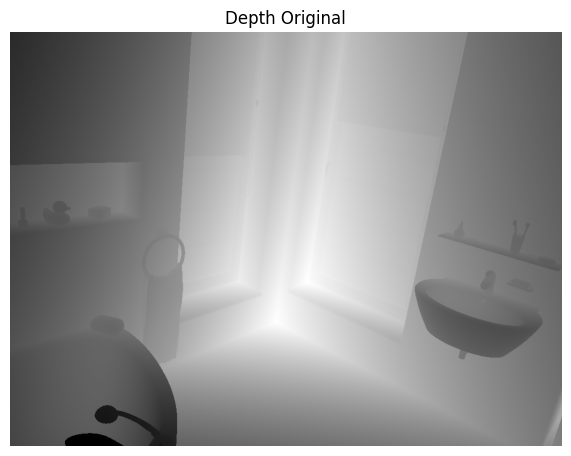

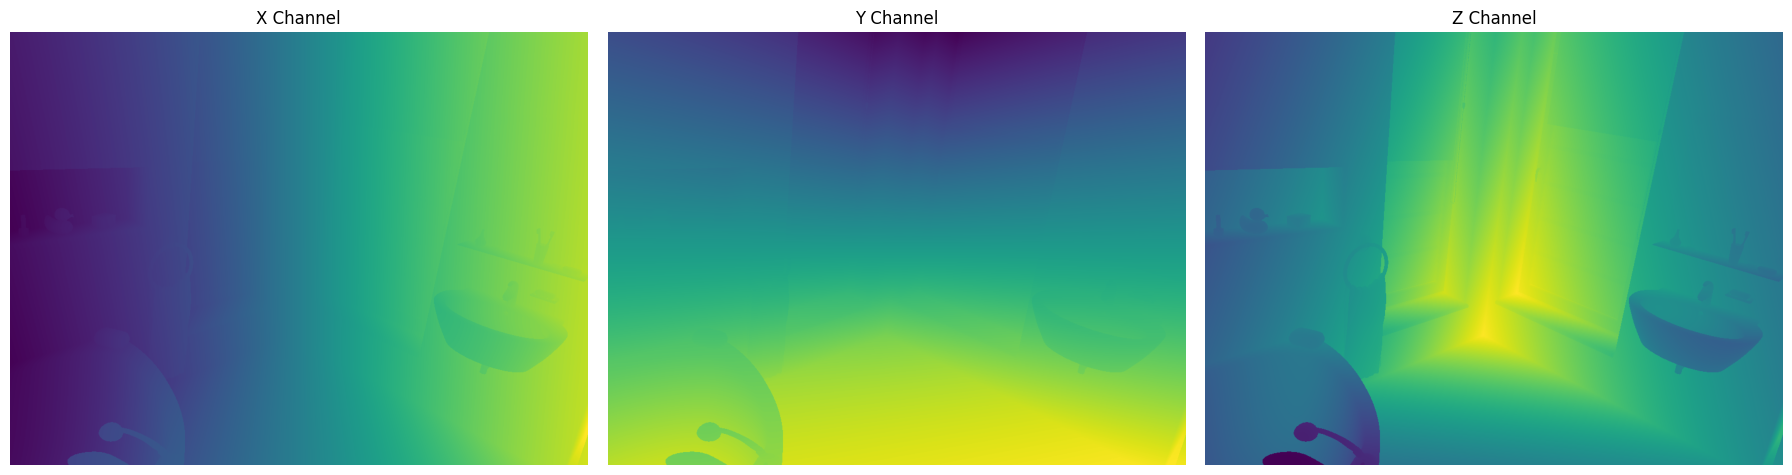

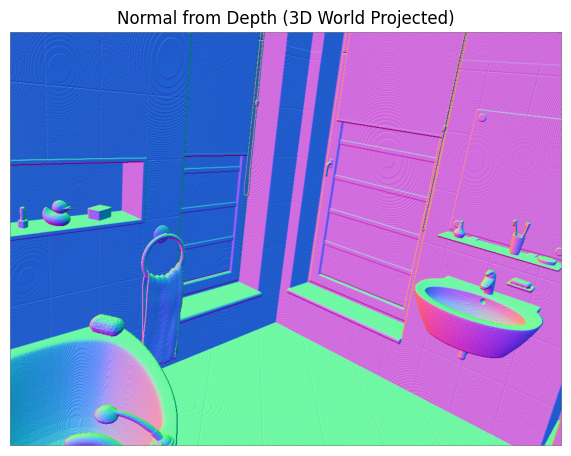

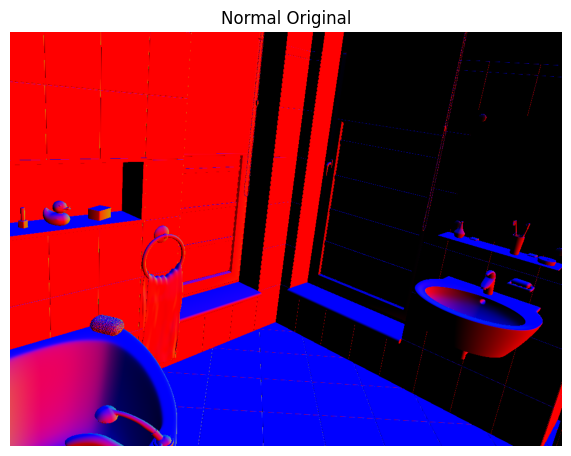

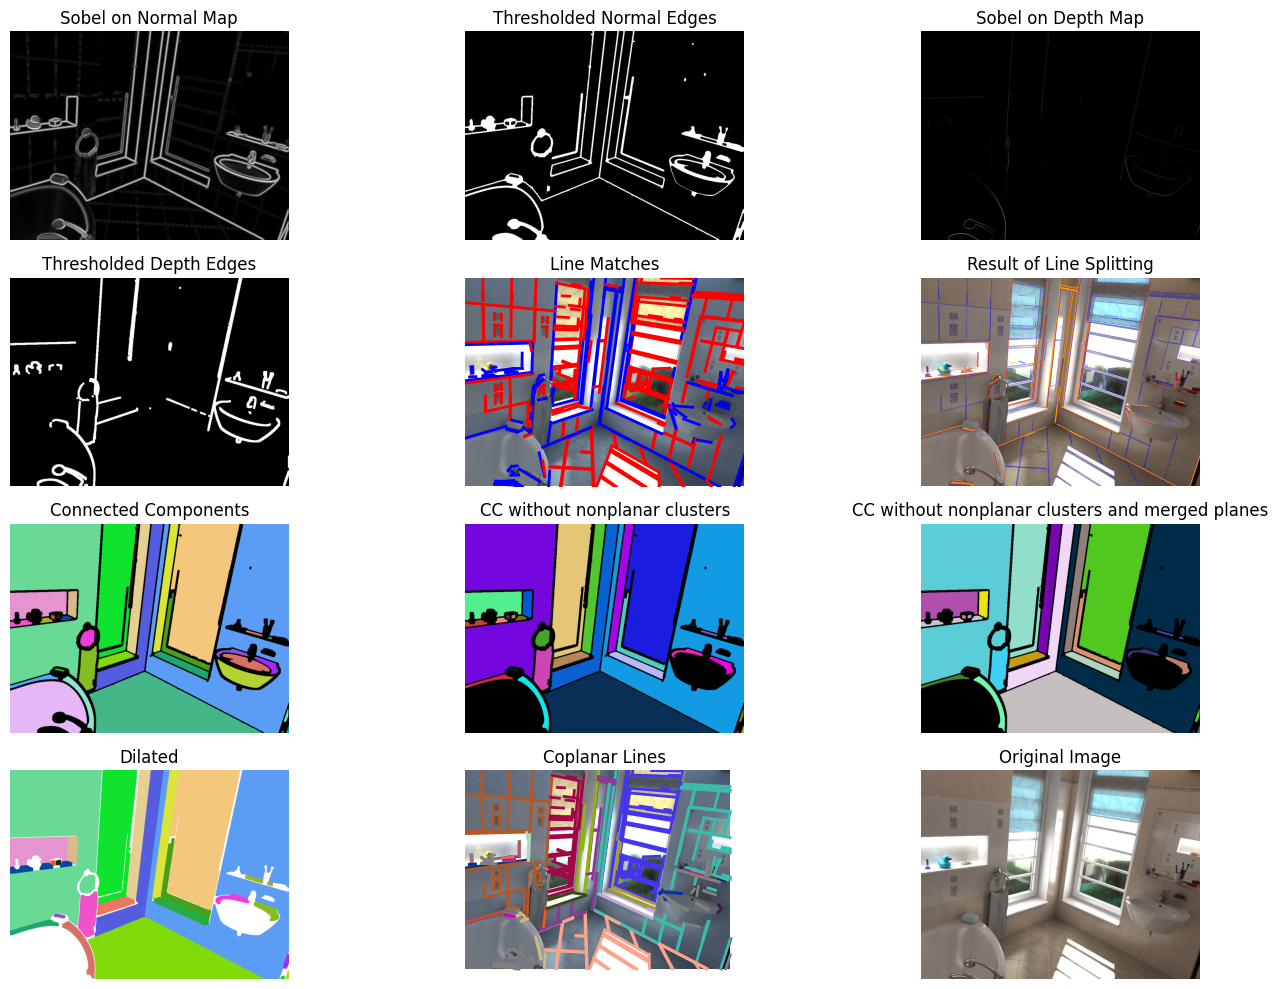

[04/16/2025 11:09:32 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Start : 1744794572.143647
data/ai_001_007/ai_001_007/images/scene_cam_00_final_preview/frame.0001.color.jpg
data/ai_001_007/ai_001_007/images/scene_cam_00_geometry_hdf5/frame.0001.depth_meters.hdf5
???
data/ai_001_007/ai_001_007/images/scene_cam_00_geometry_hdf5/frame.0001.normal_world.hdf5
Time to get depth and calculate normal map and wd : 0.18741989135742188
Time for DeepLSD : 6.37966513633728
Time to calculate sobels : 0.0695638656616211
Time for structural vs textural : 0.06467103958129883
Time for line splitting : 0.45195603370666504
Time to get CC : 0.002371072769165039
Number of connected components (including background): 83
Cluster 1: valid plane with mean error 0.0013.
Cluster 2: valid plane with mean error 0.0004.
Cluster 3: valid plane with mean error 0.0005.
Cluster 4: valid plane with mean error 0.0014.
Cluster 5: valid plane with mean error 0.0003.
Cluster 6: valid plane with mean error 0.0011.
Cluster 7: valid plane with mean error 0.0004.
Cluster 8: valid plane with m

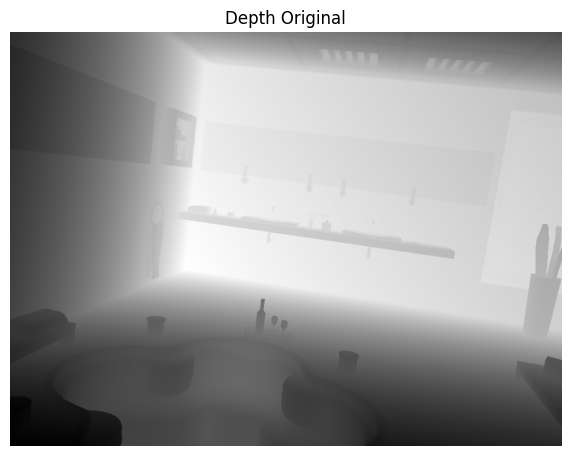

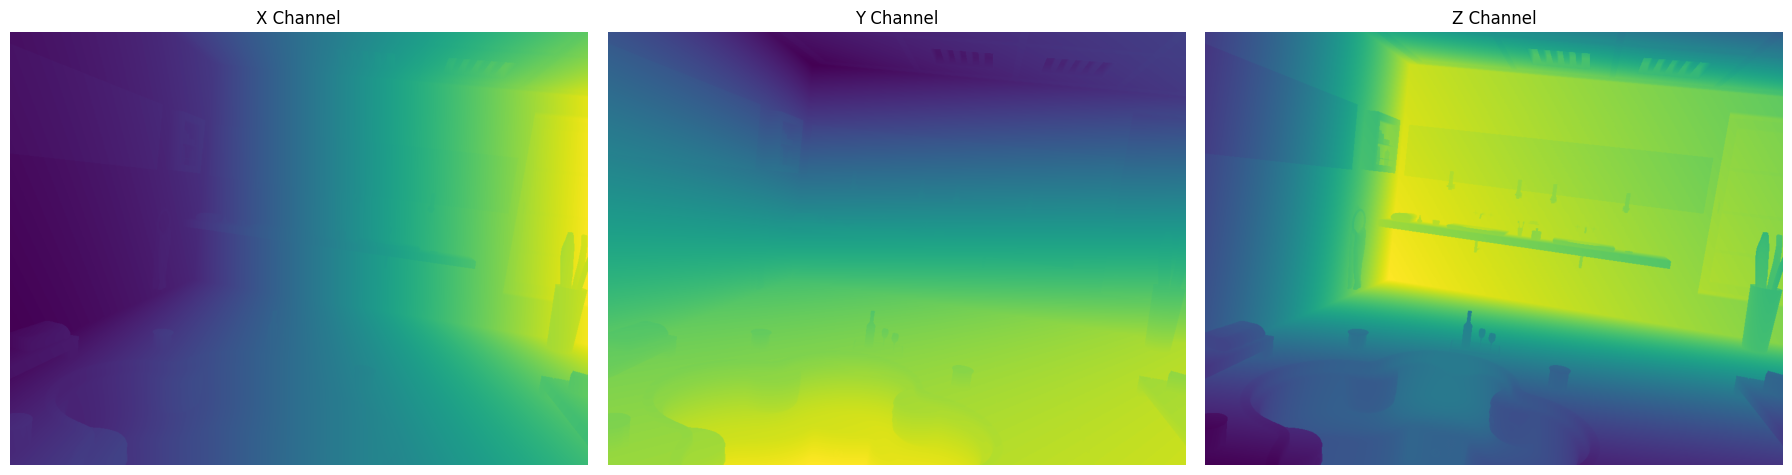

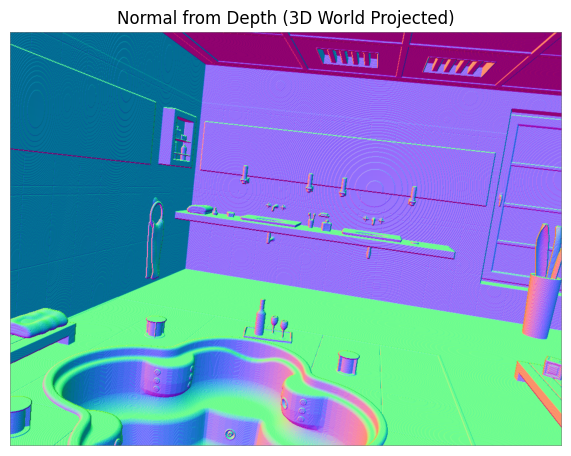

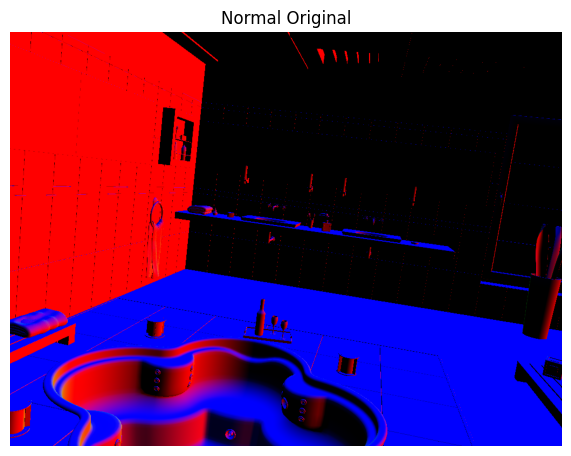

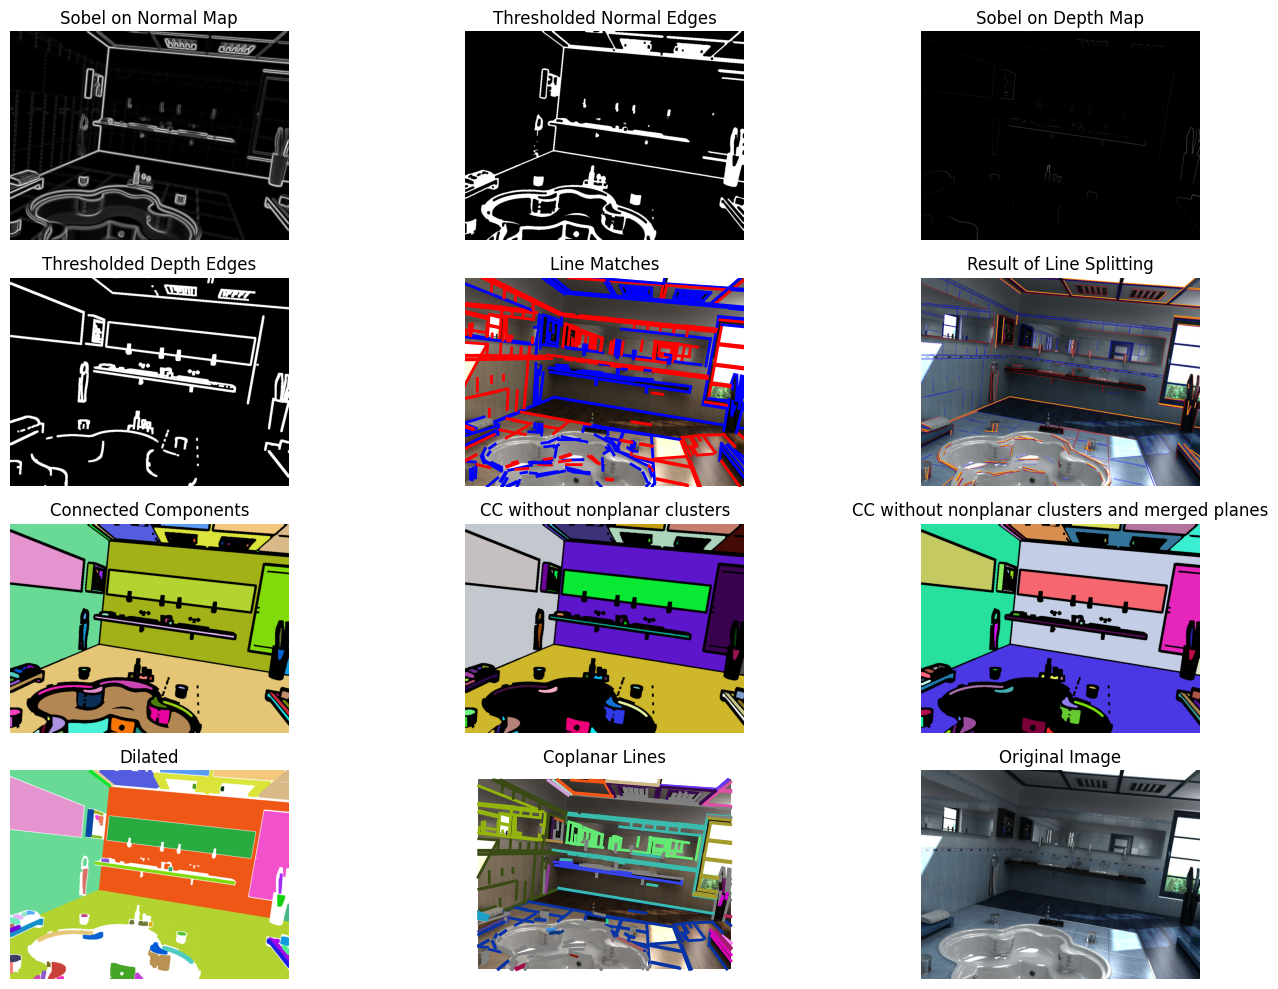

[04/16/2025 11:09:43 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Start : 1744794583.255214
data/ai_001_008/ai_001_008/images/scene_cam_00_final_preview/frame.0001.color.jpg
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.depth_meters.hdf5
???
data/ai_001_008/ai_001_008/images/scene_cam_00_geometry_hdf5/frame.0001.normal_world.hdf5
Time to get depth and calculate normal map and wd : 0.17695188522338867
Time for DeepLSD : 6.476734161376953
Time to calculate sobels : 0.06806302070617676
Time for structural vs textural : 0.05444788932800293
Time for line splitting : 0.11096405982971191
Time to get CC : 0.0015399456024169922
Number of connected components (including background): 56
Cluster 1: valid plane with mean error 0.0002.
Cluster 2: valid plane with mean error 0.0016.
Cluster 3: valid plane with mean error 0.0002.
Cluster 4: valid plane with mean error 0.0002.
Cluster 5: valid plane with mean error 0.0015.
Cluster 6: valid plane with mean error 0.0006.
Cluster 7: valid plane with mean error 0.0054.
Cluster 9: valid plane wit

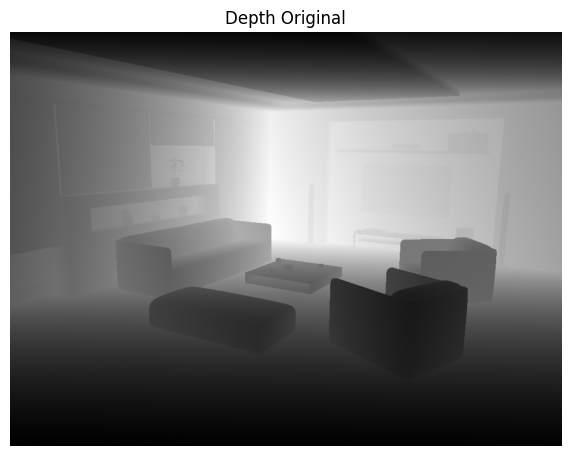

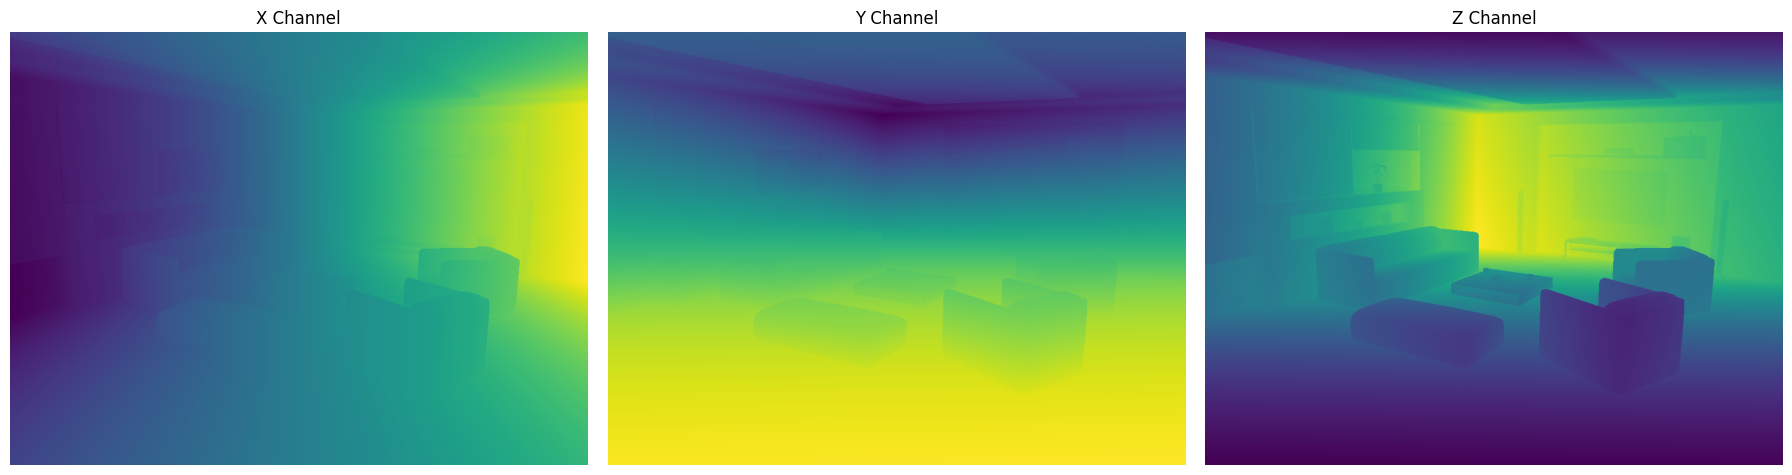

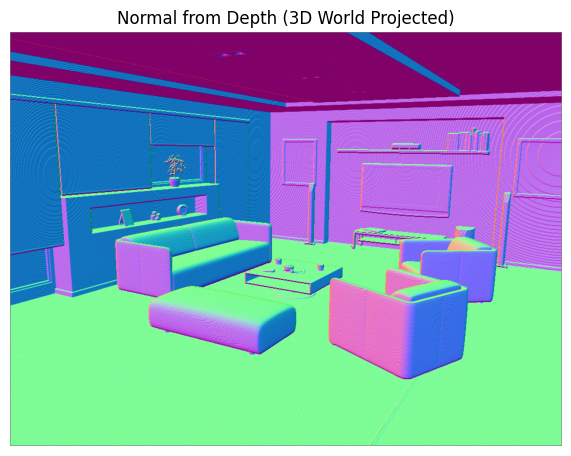

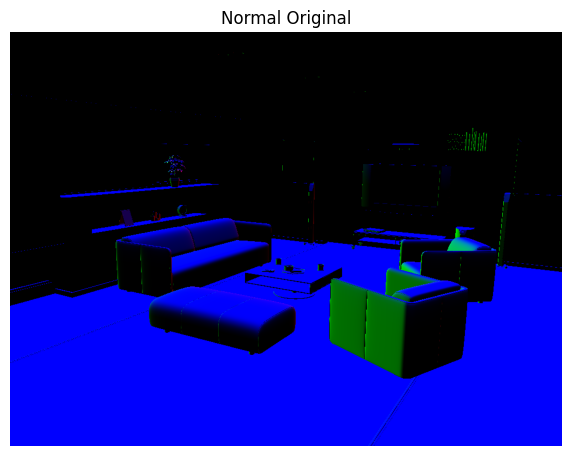

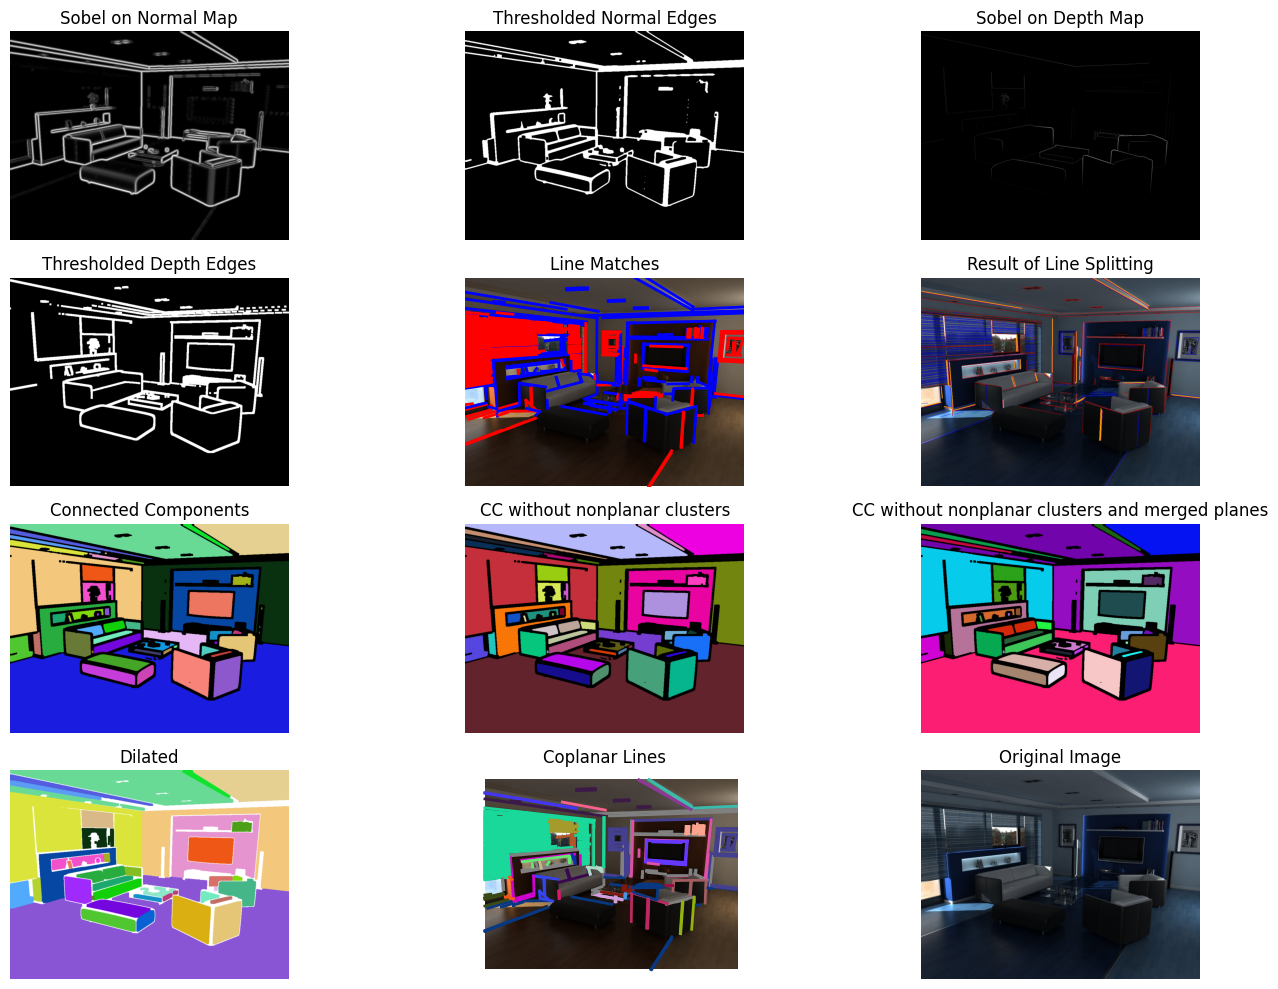

[04/16/2025 11:09:54 WARNING] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


Start : 1744794594.0290408
data/ai_001_009/ai_001_009/images/scene_cam_00_final_preview/frame.0001.color.jpg
data/ai_001_009/ai_001_009/images/scene_cam_00_geometry_hdf5/frame.0001.depth_meters.hdf5
???
data/ai_001_009/ai_001_009/images/scene_cam_00_geometry_hdf5/frame.0001.normal_world.hdf5
Time to get depth and calculate normal map and wd : 0.19029617309570312


KeyboardInterrupt: 

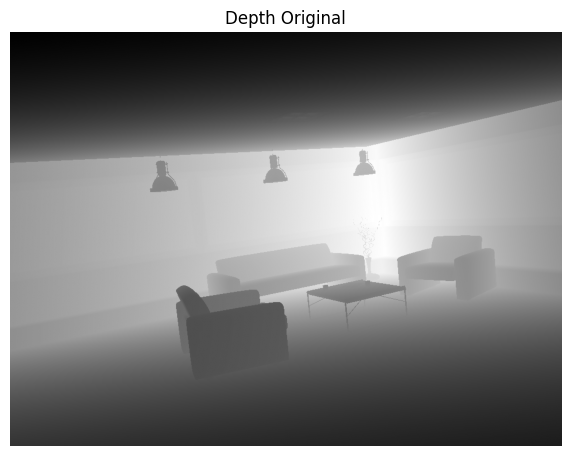

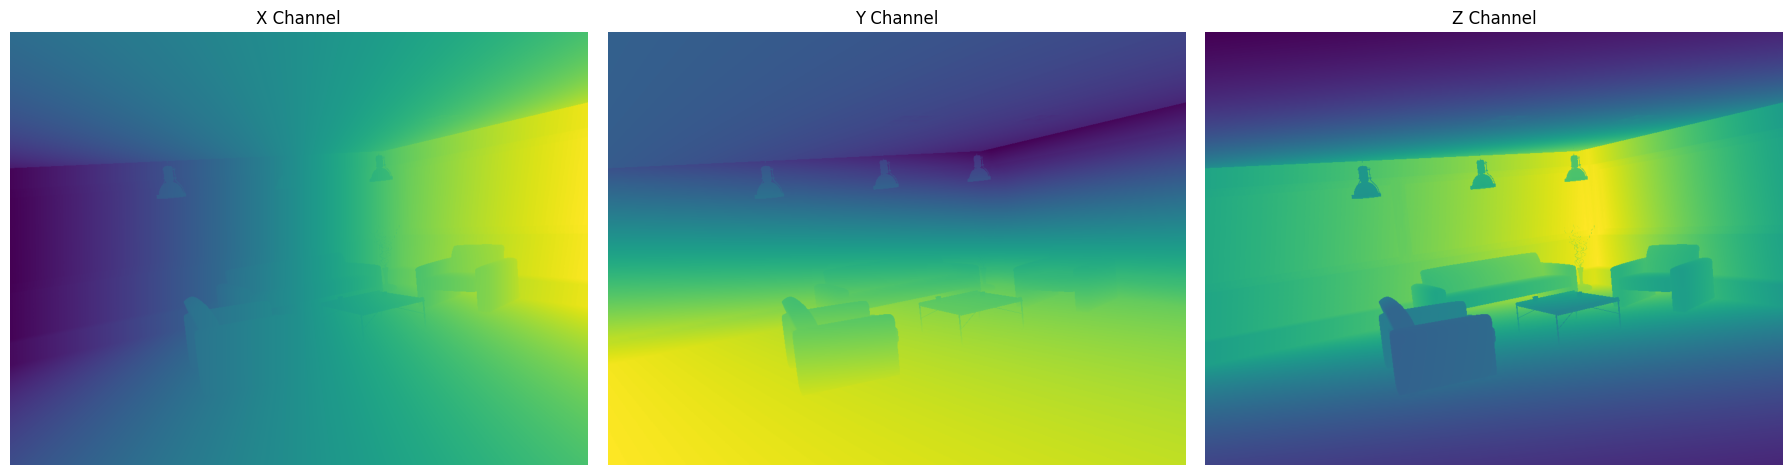

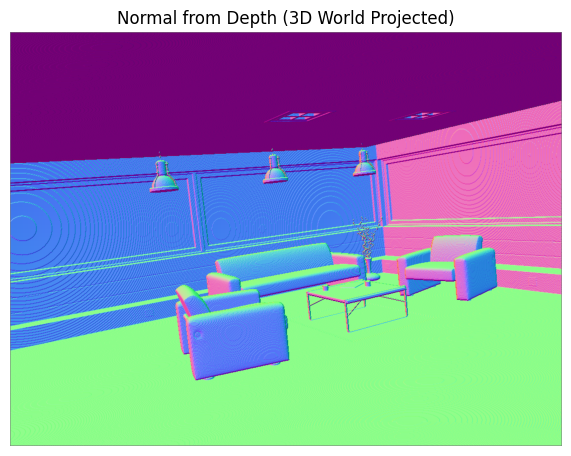

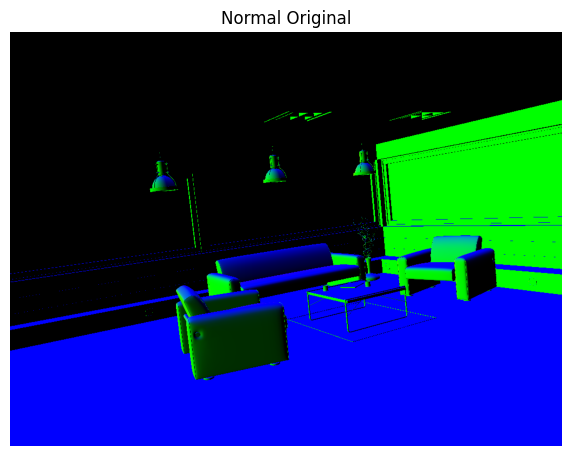

In [363]:
frame_str = "0001"
desired_images = [
    "ai_001_001",
    # "ai_001_004",
    # "ai_001_005",
    # "ai_001_006",
    "ai_001_007",
    "ai_001_008",
    "ai_001_009",
    "ai_002_001",

    #"DSC_0442",
    #"DSC_0455",
    #"DSC_0239",
    #"DSC_0249",
]

#moge = MoGeModel.from_pretrained("Ruicheng/moge-vitl").to(device)

# Process, plot, and save JSON data for each image.
for image_id in desired_images:
    #composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines
    # Load the model from huggingface hub (or load from local).
    image_dir = os.path.join("data", image_id)
    composite_after, pred_lines, img, normals, world_coordinates, valid_mask, line_info, scores, isstruct, original_lines = process_image(
        image_dir, image_id, frame_str, net, device,
        depth_thresh=50, normal_thresh=1.5 * 1e7,
        dataset="hypersim"
        #moge_model = moge
    )
    